# 📊 Students Performance — Statistical Analysis Report

**Goal:** Apply statistical methods to understand what factors influence student exam scores.

**Dataset:** Students Performance in Exams (Kaggle)

---

### Questions we answer:

1. What do the score distributions look like — and are they normal?
2. How strongly do math, reading, and writing scores correlate?
3. Which students are statistical outliers and why does it matter?
4. Does test preparation actually improve math scores? *(Hypothesis Test 1)*
5. Do reading scores differ significantly by gender? *(Hypothesis Test 2)*

---

---
## ***📦Imports & 📥Load***
---

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
df = pd.read_csv(
    "StudentsPerformance.csv",
    quotechar='"',        # treat " as the quote character
    skipinitialspace=True # strip spaces after the delimiter
)
df.columns = df.columns.str.strip()
df = df.apply(lambda col: col.str.strip() if hasattr(col, 'str') else col)
print("Shape :", df.shape)
print("Dtypes:\n", df.dtypes)
print("\nNull counts:\n", df.isnull().sum())

Shape : (1000, 8)
Dtypes:
 gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

Null counts:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


---
## ***📦1: Dataset Overview***
---

In [100]:
print("=== DATASET OVERVIEW ===\n")
print(df.describe().round(2))
print("\nCategorical columns:")
for col in df.select_dtypes(include=["object", "string"]).columns:
    print(f"  {col}: {df[col].unique()}")

=== DATASET OVERVIEW ===

       math score  reading score  writing score
count     1000.00        1000.00        1000.00
mean        66.09          69.17          68.05
std         15.16          14.60          15.20
min          0.00          17.00          10.00
25%         57.00          59.00          57.75
50%         66.00          70.00          69.00
75%         77.00          79.00          79.00
max        100.00         100.00         100.00

Categorical columns:
  gender: <ArrowStringArray>
['female', 'male']
Length: 2, dtype: str
  race/ethnicity: <ArrowStringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
  parental level of education: <ArrowStringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
  lunch: <ArrowStringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
  test preparation course: <ArrowStringArray>
['no

---
## ***📐 2. Descriptive Statistics***
---

In [101]:
def manual_mean(x):     return sum(x) / len(x)
def manual_variance(x):
    m = manual_mean(x)
    return sum((xi - m)**2 for xi in x) / len(x)
def manual_std(x):      return manual_variance(x) ** 0.5

print("=== DESCRIPTIVE STATISTICS ===\n")
subjects = ["math score", "reading score", "writing score"]

for s in subjects:
    vals = df[s].values
    print(f"{s}")
    print(f"  Mean     : {manual_mean(vals):.3f}")
    print(f"  Variance : {manual_variance(vals):.3f}  (population, ÷N)")
    print(f"  Std Dev  : {manual_std(vals):.3f}")
    print(f"  NumPy verify — mean: {np.mean(vals):.3f}  std: {np.std(vals):.3f}\n")

=== DESCRIPTIVE STATISTICS ===

math score
  Mean     : 66.089
  Variance : 229.689  (population, ÷N)
  Std Dev  : 15.155
  NumPy verify — mean: 66.089  std: 15.155

reading score
  Mean     : 69.169
  Variance : 212.952  (population, ÷N)
  Std Dev  : 14.593
  NumPy verify — mean: 69.169  std: 14.593

writing score
  Mean     : 68.054
  Variance : 230.677  (population, ÷N)
  Std Dev  : 15.188
  NumPy verify — mean: 68.054  std: 15.188



---
## ***📈 3. Score Distributions***
---

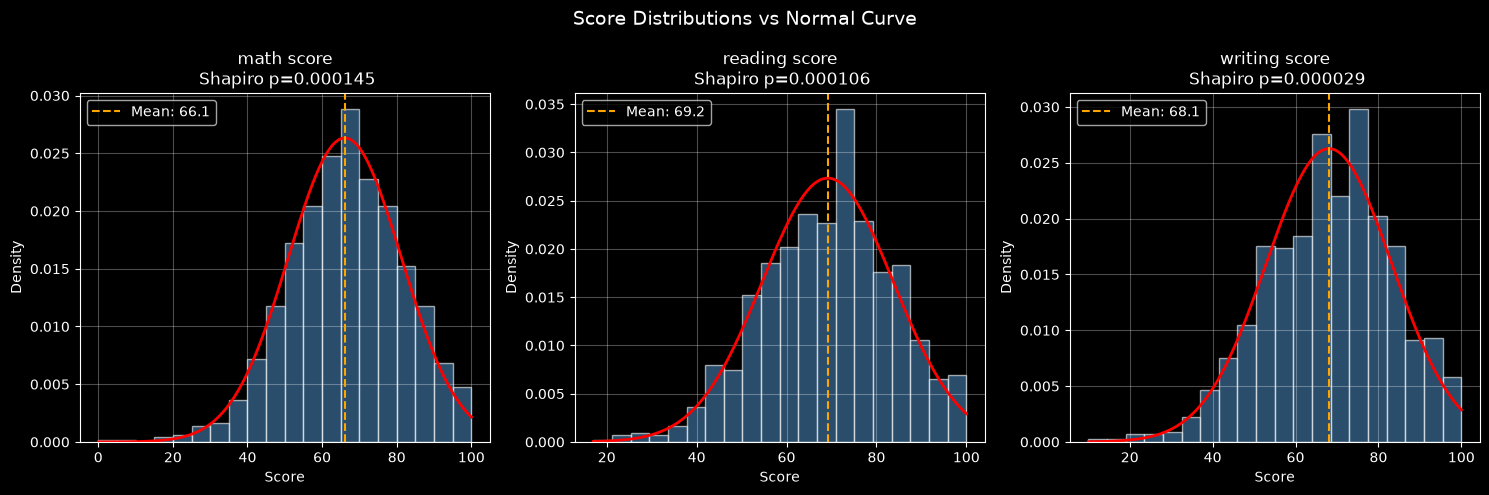

In [113]:
fig,axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Score Distributions vs Normal Curve", fontsize=14)
for ax, subject in zip(axes, subjects):
    vals = df[subject].values
    mu, sigma = np.mean(vals), np.std(vals)

    ax.hist(vals, bins=20, density=True, alpha=0.6, color="steelblue", edgecolor="white")
    x = np.linspace(vals.min(), vals.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), "r-", linewidth=2)
    ax.axvline(mu, color="orange", linestyle="--", linewidth=1.5, label=f"Mean: {mu:.1f}")
    stat, p = stats.shapiro(vals)
    ax.set_title(f"{subject}\n Shapiro p={p:.6f}")
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

---
## ***🔗 4. Correlation Matrix***
---

=== CORRELATION MATRIX ===

               math score  reading score  writing score
math score         1.0000         0.8176         0.8026
reading score      0.8176         1.0000         0.9546
writing score      0.8026         0.9546         1.0000


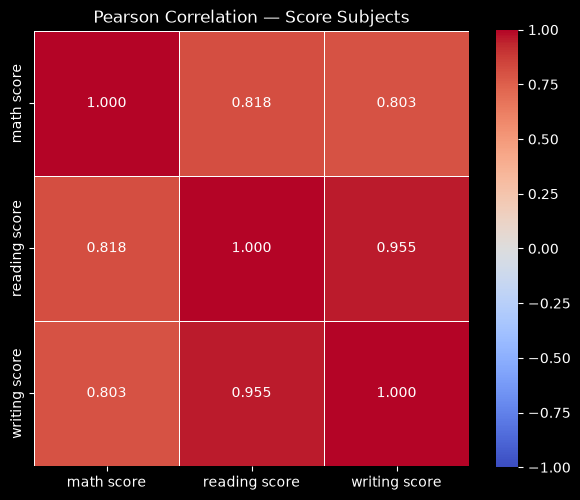


Interpretation:
  Reading–Writing : strongest correlation (0.955) — both driven by language ability
  Math–Reading    : strong but weaker (0.818) — some overlap, different skill base
  Math–Writing    : similar to above (0.803)
  None of these imply causation — shared academic preparedness is a likely confounder


In [114]:
import seaborn as sns
corr = df[subjects].corr()
print("=== CORRELATION MATRIX ===\n")
print(corr.round(4))
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5, ax=ax, square=True)
ax.set_title("Pearson Correlation — Score Subjects")
plt.tight_layout()
plt.show()
print("\nInterpretation:")
print("  Reading–Writing : strongest correlation (0.955) — both driven by language ability")
print("  Math–Reading    : strong but weaker (0.818) — some overlap, different skill base")
print("  Math–Writing    : similar to above (0.803)")
print("  None of these imply causation — shared academic preparedness is a likely confounder")

---
## ***🎯 5: Z-score Outlier Analysis***
---

=== Z-SCORE OUTLIER ANALYSIS ===

math score
Outliers |z|>2 : 46 / 1000  (4.6%)
  Extreme |z|>3 : 
     math score         z
17           18 -3.173040
59            0 -4.360728
787          19 -3.107058
980           8 -3.832867

reading score
Outliers |z|>2 : 46 / 1000  (4.6%)
  Extreme |z|>3 : 
     reading score         z
59              17 -3.574960
327             23 -3.163801
596             24 -3.095274
980             24 -3.095274

writing score
Outliers |z|>2 : 42 / 1000  (4.2%)
  Extreme |z|>3 : 
     writing score         z
59              10 -3.822345
76              22 -3.032251
327             19 -3.229774
596             15 -3.493139



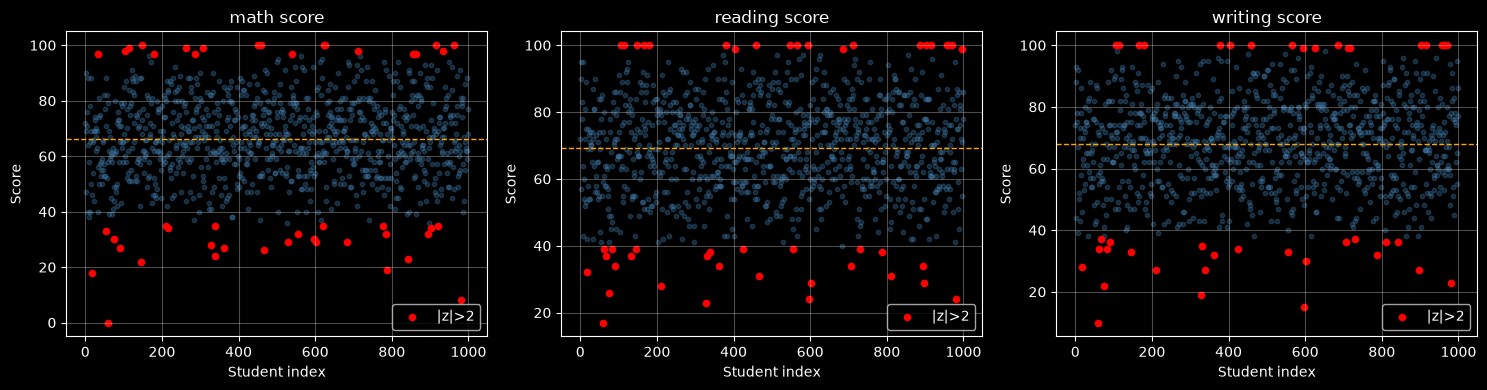

In [112]:
print("=== Z-SCORE OUTLIER ANALYSIS ===\n")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, subject in zip(axes, subjects):
    vals = df[subject].values
    mu, sigma = np.mean(vals), np.std(vals)
    zscores = (vals - mu) / sigma
    outliers = np.sum(np.abs(zscores) > 2)
    print(f"{subject}")
    print(f"Outliers |z|>2 : {outliers} / {len(vals)}  ({100*outliers/len(vals):.1f}%)")
    extreme = df[np.abs(zscores) > 3][[subject]].copy()
    extreme["z"] = zscores[np.abs(zscores) > 3]
    if len(extreme):
        print(f"  Extreme |z|>3 : \n{extreme.to_string()}\n")
    else:
        print("  No extreme outliers\n")
    ax.scatter(range(len(vals)), vals, alpha=0.3, s=10, color="steelblue")
    ax.scatter(np.where(np.abs(zscores) > 2)[0], vals[np.abs(zscores) > 2], color="red", s=20, label="|z|>2")
    ax.axhline(mu, color="orange", linestyle="--", linewidth=1)
    ax.set_title(subject)
    ax.set_xlabel("Student index")
    ax.set_ylabel("Score")
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

---
## ***🧪 6.1: Hypothesis Test 1 — Test Prep vs Math Score***
---

=== HYPOTHESIS TEST 1: Test Prep vs Math Score ===

H₀: No difference in mean math scores between prep and no-prep groups
H₁: Test prep group has a significantly different mean math score

Prep group    | n: 358  | mean: 69.70  | std: 14.42
No prep group | n: 642 | mean: 64.08 | std: 15.18
Mean difference: 5.62 points

t-statistic : 5.7046
p-value     : 1.54e-08

Conclusion : Reject H₀ — test prep has a statistically significant effect on math scores
Note       : Significant ≠ causal — motivated students may self-select into test prep


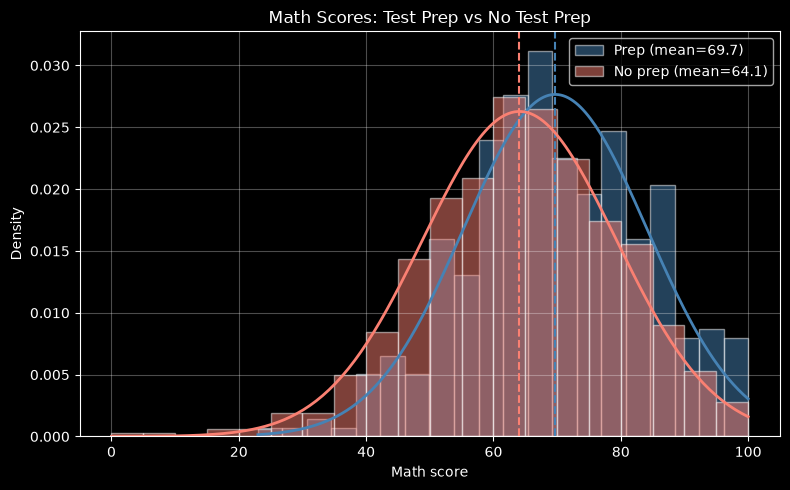

In [116]:
print("=== HYPOTHESIS TEST 1: Test Prep vs Math Score ===\n")
print("H₀: No difference in mean math scores between prep and no-prep groups")
print("H₁: Test prep group has a significantly different mean math score\n")

prep    = df[df["test preparation course"] == "completed"]["math score"].values
no_prep = df[df["test preparation course"] == "none"]["math score"].values

print(f"Prep group    | n: {len(prep)}  | mean: {prep.mean():.2f}  | std: {prep.std():.2f}")
print(f"No prep group | n: {len(no_prep)} | mean: {no_prep.mean():.2f} | std: {no_prep.std():.2f}")
print(f"Mean difference: {prep.mean() - no_prep.mean():.2f} points\n")

t_stat, p_value = stats.ttest_ind(prep, no_prep)
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.2e}")

if p_value < 0.05:
    print("\nConclusion : Reject H₀ — test prep has a statistically significant effect on math scores")
    print("Note       : Significant ≠ causal — motivated students may self-select into test prep")
else:
    print("\nConclusion : Fail to reject H₀ — difference could be random chance")
    
fig, ax = plt.subplots(figsize=(8, 5))
for group, color, label in [(prep, "steelblue", f"Prep (mean={prep.mean():.1f})"), (no_prep, "salmon",    f"No prep (mean={no_prep.mean():.1f})")]:
    ax.hist(group, bins=20, alpha=0.5, density=True, edgecolor="white", color=color, label=label)
    mu, sigma = group.mean(), group.std()
    x = np.linspace(group.min(), group.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color=color, linewidth=2)
    ax.axvline(mu, color=color, linestyle="--", linewidth=1.5)
ax.set_title("Math Scores: Test Prep vs No Test Prep")
ax.set_xlabel("Math score")
ax.set_ylabel("Density")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

---
## ***🧪 6.2: Hypothesis Test 2 — Gender vs Reading Score***
---

=== HYPOTHESIS TEST 2: Gender vs Reading Score ===

H₀: No difference in mean reading scores between male and female students
H₁: A statistically significant difference in reading scores exists between genders

Female | n: 518 | mean: 72.61 | std: 14.36
Male   | n: 482   | mean: 65.47   | std: 13.92
t-statistic : 7.9593
p-value     : 4.68e-15

Conclusion : Reject H₀ — statistically significant difference in reading scores by gender
Note       : This is observational data — biological, social, and educational factors
             are all confounded here. The stat is real; the cause is not established.


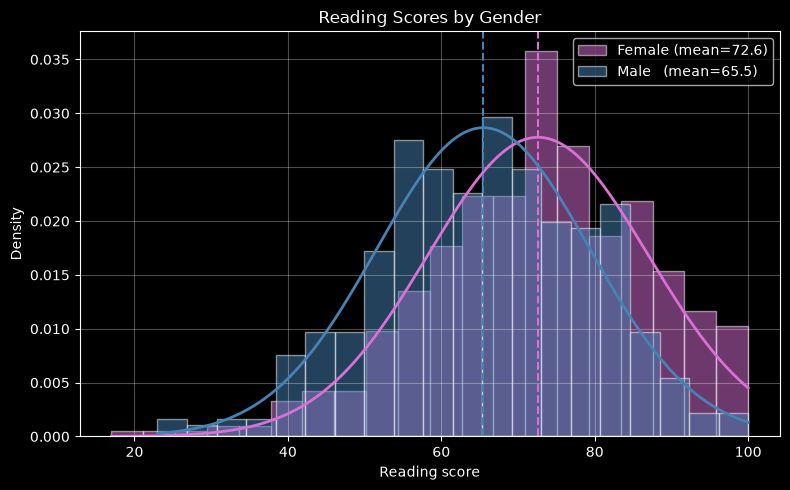

In [108]:
print("=== HYPOTHESIS TEST 2: Gender vs Reading Score ===\n")
print("H₀: No difference in mean reading scores between male and female students")
print("H₁: A statistically significant difference in reading scores exists between genders\n")
female = df[df["gender"] == "female"]["reading score"].values
male = df[df["gender"] == "male"]["reading score"].values
print(f"Female | n: {len(female)} | mean: {female.mean():.2f} | std: {female.std():.2f}")
print(f"Male   | n: {len(male)}   | mean: {male.mean():.2f}   | std: {male.std():.2f}")
t_stat, p_value = stats.ttest_ind(female, male)
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.2e}")

if p_value < 0.05:
    print("\nConclusion : Reject H₀ — statistically significant difference in reading scores by gender")
    print("Note       : This is observational data — biological, social, and educational factors")
    print("             are all confounded here. The stat is real; the cause is not established.")
else:
    print("\nConclusion : Fail to reject H₀ — difference could be random chance")

fig, ax = plt.subplots(figsize=(8, 5))
for group, color, label in [(female, "orchid", f"Female (mean={female.mean():.1f})"), (male, "steelblue", f"Male   (mean={male.mean():.1f})")]:
    ax.hist(group, bins=20, alpha=0.5, density=True, edgecolor="white", color=color, label=label)
    mu, sigma = group.mean(), group.std()
    x = np.linspace(group.min(), group.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color=color, linewidth=2)
    ax.axvline(mu, color=color, linestyle="--", linewidth=1.5)
ax.set_title("Reading Scores by Gender")
ax.set_xlabel("Reading score")
ax.set_ylabel("Density")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [107]:
plt.style.use('dark_background')

---
## ***✅ 7. Conclusions***
---

In [117]:
print("""
=== CONCLUSIONS ===

1. DESCRIPTIVE STATS
   All three subjects have similar means (60–70 range) and std devs (~14–15),
   suggesting comparable difficulty. Writing and reading are more tightly distributed
   than math, which shows slightly more spread.

2. DISTRIBUTIONS
   All three subjects approximate a normal distribution visually, though Shapiro-Wilk
   formally rejects perfect normality — expected with n=1000 where the test is very
   sensitive to tiny deviations. For practical purposes, normality holds well enough
   for t-tests.

3. CORRELATION
   Reading and writing are very strongly correlated (0.955), sharing a common language
   skill base. Math correlates moderately with both (~0.80), reflecting partial overlap
   in general academic ability. None of these correlations imply causation — shared
   academic preparedness is the likely confounding variable.

4. OUTLIERS
   ~4–5% of students per subject fall beyond |z|>2, consistent with the ~5% a true
   normal distribution predicts. The student with math score=0 is a notable extreme
   outlier (|z|>4) — likely absent or non-participating rather than genuine performance.

5. HYPOTHESIS TEST 1 — Test Prep vs Math Score
   A statistically significant 5.6-point gap was found (t=5.70, p=1.54e-08).
   Test prep is associated with higher scores, but self-selection bias likely confounds
   the result — motivated students may both enrol in test prep and study harder anyway.

6. HYPOTHESIS TEST 2 — Gender vs Reading Score
   Female students scored 7.14 points higher on average (72.61 vs 65.47).
   The difference is highly statistically significant (t=7.96, p=4.68e-15) —
   one of the strongest effects in this dataset. However, this is purely observational:
   biological, social, cultural, and educational factors are all tangled together here.
   The stat establishes that the gap is real and not random noise; it does not establish
   why it exists or whether any single factor causes it.

7. OVERALL
   The data tells a consistent story: academic performance is influenced by preparation,
   resources, and group-level patterns that are real but not simply explainable. Every significant
   result here is an association, not a cause — the right next step for any of these
   questions is a controlled study, not more observational analysis.
""")


=== CONCLUSIONS ===

1. DESCRIPTIVE STATS
   All three subjects have similar means (60–70 range) and std devs (~14–15),
   suggesting comparable difficulty. Writing and reading are more tightly distributed
   than math, which shows slightly more spread.

2. DISTRIBUTIONS
   All three subjects approximate a normal distribution visually, though Shapiro-Wilk
   formally rejects perfect normality — expected with n=1000 where the test is very
   sensitive to tiny deviations. For practical purposes, normality holds well enough
   for t-tests.

3. CORRELATION
   Reading and writing are very strongly correlated (0.955), sharing a common language
   skill base. Math correlates moderately with both (~0.80), reflecting partial overlap
   in general academic ability. None of these correlations imply causation — shared
   academic preparedness is the likely confounding variable.

4. OUTLIERS
   ~4–5% of students per subject fall beyond |z|>2, consistent with the ~5% a true
   normal distribution p